In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
customers = pd.read_csv("/content/customers (1).csv")
products = pd.read_csv("/content/products (1).csv")
transactions = pd.read_csv("/content/transactions.csv")
data_dictionary = pd.read_csv("/content/data_dictionary.csv")

In [4]:
customers

,customer_id,age,gender,city,membership,join_date
0,1,26,Male,Dallas,Silver,2022-10-11
1,2,66,Female,Seattle,Platinum,2022-02-16
2,3,68,Male,New York,Gold,2020-02-28
3,4,42,Female,Miami,Silver,2023-11-26
4,5,46,Female,Chicago,Platinum,2025-04-19
...,...,...,...,...,...,...
995,996,21,Female,New York,Silver,2020-06-11
996,997,56,Female,New York,Platinum,2021-05-17
997,998,26,Female,Miami,Gold,2021-03-31
998,999,55,Female,Chicago,Platinum,2021-03-22


In [5]:
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Transactions:", transactions.shape)
print("Data Dictionary:", data_dictionary.shape)

Customers: (1000, 6)
Products: (500, 5)
Transactions: (20000, 9)
Data Dictionary: (3, 3)


In [6]:
customers.head()

,customer_id,age,gender,city,membership,join_date
0,1,26,Male,Dallas,Silver,2022-10-11
1,2,66,Female,Seattle,Platinum,2022-02-16
2,3,68,Male,New York,Gold,2020-02-28
3,4,42,Female,Miami,Silver,2023-11-26
4,5,46,Female,Chicago,Platinum,2025-04-19


In [7]:
products.head()

,product_id,category,product_name,brand,price
0,1,Sports,Product 1,Brand 8,65.39
1,2,Sports,Product 2,Brand 18,106.32
2,3,Electronics,Product 3,Brand 14,226.75
3,4,Clothing,Product 4,Brand 6,287.96
4,5,Home,Product 5,Brand 28,310.90


In [8]:
transactions.head()

,transaction_id,customer_id,product_id,purchase_date,quantity,unit_price,discount,payment_method,total_amount
0,1,95,143,2025-05-18,4,199.16,20,UPI,637.31
1,2,620,150,2024-02-27,4,481.00,0,Cash,1924.00
2,3,205,359,2025-05-16,4,65.07,10,Card,234.25
3,4,84,17,2023-04-03,3,125.96,15,Cash,321.20
4,5,34,453,2023-03-08,4,70.72,15,Card,240.45


In [9]:
print("CUSTOMERS")
customers.info()

print("\nPRODUCTS")
products.info()

print("\nTRANSACTIONS")
transactions.info()

CUSTOMERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  1000 non-null   int64 
 1   age          1000 non-null   int64 
 2   gender       1000 non-null   object
 3   city         1000 non-null   object
 4   membership   1000 non-null   object
 5   join_date    1000 non-null   object
dtypes: int64(2), object(4)
memory usage: 47.0+ KB

PRODUCTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    500 non-null    int64  
 1   category      500 non-null    object 
 2   product_name  500 non-null    object 
 3   brand         500 non-null    object 
 4   price         500 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 19.7+ KB

TRANSACTIONS
<class 'pandas

In [10]:
print("Customers Missing Values")
print(customers.isnull().sum())

print("\nProducts Missing Values")
print(products.isnull().sum())

print("\nTransactions Missing Values")
print(transactions.isnull().sum())

Customers Missing Values
customer_id    0
age            0
gender         0
city           0
membership     0
join_date      0
dtype: int64

Products Missing Values
product_id      0
category        0
product_name    0
brand           0
price           0
dtype: int64

Transactions Missing Values
transaction_id    0
customer_id       0
product_id        0
purchase_date     0
quantity          0
unit_price        0
discount          0
payment_method    0
total_amount      0
dtype: int64


In [11]:
def missing_percentage(df):
    return (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

print(missing_percentage(customers))
print(missing_percentage(products))
print(missing_percentage(transactions))

customer_id    0.0
age            0.0
gender         0.0
city           0.0
membership     0.0
join_date      0.0
dtype: float64
product_id      0.0
category        0.0
product_name    0.0
brand           0.0
price           0.0
dtype: float64
transaction_id    0.0
customer_id       0.0
product_id        0.0
purchase_date     0.0
quantity          0.0
unit_price        0.0
discount          0.0
payment_method    0.0
total_amount      0.0
dtype: float64


In [12]:
print("Duplicate customers:", customers.duplicated().sum())

Duplicate customers: 0


In [13]:
print("Duplicate products:", products.duplicated().sum())

Duplicate products: 0


In [14]:
print("Duplicate transactions:", transactions.duplicated().sum())

Duplicate transactions: 0


In [15]:
print("Duplicate Customer IDs:", customers["customer_id"].duplicated().sum())
print("Duplicate Product IDs:", products["product_id"].duplicated().sum())
print("Duplicate Transaction IDs:", transactions["transaction_id"].duplicated().sum())

Duplicate Customer IDs: 0
Duplicate Product IDs: 0
Duplicate Transaction IDs: 0


In [16]:
print(customers["gender"].value_counts())
print(customers["membership"].value_counts())
print(customers["city"].value_counts())

gender
Male      517
Female    483
Name: count, dtype: int64
membership
Gold        356
Platinum    345
Silver      299
Name: count, dtype: int64
city
Miami       227
Dallas      201
Chicago     195
Seattle     190
New York    187
Name: count, dtype: int64


In [17]:
print(products["category"].value_counts())
print(products["brand"].value_counts())

category
Books          106
Clothing       105
Home           102
Sports          95
Electronics     92
Name: count, dtype: int64
brand
Brand 29    26
Brand 5     24
Brand 15    21
Brand 14    21
Brand 4     20
Brand 28    19
Brand 16    19
Brand 23    18
Brand 26    18
Brand 12    18
Brand 10    18
Brand 1     17
Brand 30    17
Brand 11    17
Brand 21    17
Brand 2     17
Brand 17    16
Brand 9     15
Brand 19    15
Brand 20    15
Brand 6     15
Brand 7     15
Brand 3     15
Brand 18    14
Brand 27    14
Brand 24    13
Brand 25    13
Brand 13    12
Brand 22    11
Brand 8     10
Name: count, dtype: int64


In [18]:
print(transactions["payment_method"].value_counts())
print(transactions["discount"].value_counts())

payment_method
PayPal    5112
Card      5011
UPI       4992
Cash      4885
Name: count, dtype: int64
discount
0     4032
20    4006
5     4000
15    3988
10    3974
Name: count, dtype: int64


In [19]:
customers.describe()

,customer_id,age
count,1000.000000,1000.000000
mean,500.500000,44.438000
std,288.819436,15.363013
min,1.000000,18.000000
25%,250.750000,32.000000
50%,500.500000,45.000000
75%,750.250000,58.000000
max,1000.000000,70.000000


In [20]:
products.describe()

,product_id,price
count,500.000000,500.00000
mean,250.500000,253.68022
std,144.481833,141.24112
min,1.000000,5.11000
25%,125.750000,132.58000
50%,250.500000,244.94500
75%,375.250000,373.75250
max,500.000000,498.66000


In [21]:
transactions.describe()

,transaction_id,customer_id,product_id,quantity,unit_price,discount,total_amount
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.500000,501.864250,250.851650,2.993550,252.850547,9.98400,684.464661
std,5773.647028,289.035966,144.745383,1.413085,142.145306,7.08359,540.621068
min,1.000000,1.000000,1.000000,1.000000,5.000000,0.00000,4.060000
25%,5000.750000,251.000000,124.000000,2.000000,129.845000,5.00000,250.532500
50%,10000.500000,502.000000,250.000000,3.000000,252.800000,10.00000,533.085000
75%,15000.250000,754.000000,377.000000,4.000000,375.730000,15.00000,1008.425000
max,20000.000000,1000.000000,500.000000,5.000000,500.000000,20.00000,2494.700000


In [22]:
transactions[
    ["quantity", "unit_price", "discount", "total_amount"]
].head(10)

,quantity,unit_price,discount,total_amount
0,4,199.16,20,637.31
1,4,481.00,0,1924.00
2,4,65.07,10,234.25
3,3,125.96,15,321.20
4,4,70.72,15,240.45
5,2,346.29,15,588.69
6,3,274.38,0,823.14
7,5,281.69,20,1126.76
8,5,334.98,5,1591.15
9,4,25.75,10,92.70


In [23]:
transactions["calculated_amount"] = (
    transactions["quantity"] *
    transactions["unit_price"] *
    (1 - transactions["discount"])
)

In [24]:
transactions["difference"] = (
    transactions["total_amount"] -
    transactions["calculated_amount"]
)

transactions["difference"].describe()

,difference
count,2.000000e+04
mean,7.507984e+03
std,8.946342e+03
min,-4.547474e-13
25%,7.440550e+02
50%,4.411340e+03
75%,1.069304e+04
max,4.947921e+04


In [25]:
transactions[
    transactions["difference"].abs() > 0.01
].head()

,transaction_id,customer_id,product_id,purchase_date,quantity,unit_price,discount,payment_method,total_amount,calculated_amount,difference
0,1,95,143,2025-05-18,4,199.16,20,UPI,637.31,-15136.16,15773.47
2,3,205,359,2025-05-16,4,65.07,10,Card,234.25,-2342.52,2576.77
3,4,84,17,2023-04-03,3,125.96,15,Cash,321.20,-5290.32,5611.52
4,5,34,453,2023-03-08,4,70.72,15,Card,240.45,-3960.32,4200.77
5,6,507,74,2024-05-05,2,346.29,15,UPI,588.69,-9696.12,10284.81


In [26]:
customers["join_date"] = pd.to_datetime(customers["join_date"])
transactions["purchase_date"] = pd.to_datetime(transactions["purchase_date"])

In [27]:
print(customers["join_date"].min())
print(customers["join_date"].max())

print(transactions["purchase_date"].min())
print(transactions["purchase_date"].max())

2020-01-04 00:00:00
2025-06-23 00:00:00
2023-01-01 00:00:00
2025-06-19 00:00:00


In [28]:
invalid_customers = transactions[
    ~transactions["customer_id"].isin(customers["customer_id"])
]

print("Invalid customer IDs:", len(invalid_customers))

Invalid customer IDs: 0


In [29]:
invalid_products = transactions[
    ~transactions["product_id"].isin(products["product_id"])
]

print("Invalid product IDs:", len(invalid_products))

Invalid product IDs: 0


In [30]:
transaction_customer = transactions.merge(
    customers[["customer_id", "join_date"]],
    on="customer_id",
    how="left"
)

In [31]:
pre_join_transactions = transaction_customer[
    transaction_customer["purchase_date"] < transaction_customer["join_date"]
]

In [32]:
print("Transactions before customer join date:",
      len(pre_join_transactions))

print("Revenue from these transactions:",
      pre_join_transactions["total_amount"].sum())

Transactions before customer join date: 4501
Revenue from these transactions: 3083625.2199999997


In [33]:
print(
    "Percentage of transactions:",
    len(pre_join_transactions) / len(transactions) * 100
)

print(
    "Percentage of revenue:",
    pre_join_transactions["total_amount"].sum()
    / transactions["total_amount"].sum() * 100
)

Percentage of transactions: 22.505
Percentage of revenue: 22.52581760574328


In [34]:
transactions[[
    "quantity",
    "unit_price",
    "discount",
    "total_amount"
]].describe()

,quantity,unit_price,discount,total_amount
count,20000.000000,20000.000000,20000.00000,20000.000000
mean,2.993550,252.850547,9.98400,684.464661
std,1.413085,142.145306,7.08359,540.621068
min,1.000000,5.000000,0.00000,4.060000
25%,2.000000,129.845000,5.00000,250.532500
50%,3.000000,252.800000,10.00000,533.085000
75%,4.000000,375.730000,15.00000,1008.425000
max,5.000000,500.000000,20.00000,2494.700000


In [35]:
print("Negative quantity:",
      (transactions["quantity"] < 0).sum())

print("Zero quantity:",
      (transactions["quantity"] == 0).sum())

print("Negative unit price:",
      (transactions["unit_price"] < 0).sum())

print("Negative discount:",
      (transactions["discount"] < 0).sum())

print("Discount above 100%:",
      (transactions["discount"] > 1).sum())

print("Negative total amount:",
      (transactions["total_amount"] < 0).sum())

Negative quantity: 0
Zero quantity: 0
Negative unit price: 0
Negative discount: 0
Discount above 100%: 15968
Negative total amount: 0


In [36]:
transactions["discount"].value_counts().sort_index()

,count
discount,
0,4032
5,4000
10,3974
15,3988
20,4006


In [37]:
print("Discount above 100%:",
      (transactions["discount"] > 100).sum())

Discount above 100%: 0


In [38]:
transactions["calculated_amount"] = (
    transactions["quantity"]
    * transactions["unit_price"]
    * (1 - transactions["discount"] / 100)
)

In [39]:
transactions["difference"] = (
    transactions["total_amount"]
    - transactions["calculated_amount"]
)

In [40]:
print(
    "Transactions with calculation mismatch:",
    (transactions["difference"].abs() > 0.01).sum()
)

Transactions with calculation mismatch: 0


In [41]:
print("Minimum discount:", transactions["discount"].min())
print("Maximum discount:", transactions["discount"].max())

Minimum discount: 0
Maximum discount: 20


In [42]:
print("Customer join dates:")
print(customers["join_date"].min(), "to", customers["join_date"].max())

print("\nTransaction dates:")
print(transactions["purchase_date"].min(), "to", transactions["purchase_date"].max())

Customer join dates:
2020-01-04 00:00:00 to 2025-06-23 00:00:00

Transaction dates:
2023-01-01 00:00:00 to 2025-06-19 00:00:00


In [43]:
transaction_customer = transactions.merge(
    customers[["customer_id", "join_date"]],
    on="customer_id",
    how="left"
)

pre_join = transaction_customer[
    transaction_customer["purchase_date"] < transaction_customer["join_date"]
]

print("Transactions before customer join date:", len(pre_join))

print(
    "Revenue from pre-join transactions:",
    pre_join["total_amount"].sum()
)

print(
    "Percentage of transactions:",
    round(len(pre_join) / len(transactions) * 100, 2),
    "%"
)

print(
    "Percentage of revenue:",
    round(
        pre_join["total_amount"].sum()
        / transactions["total_amount"].sum() * 100,
        2
    ),
    "%"
)

Transactions before customer join date: 4501
Revenue from pre-join transactions: 3083625.2199999997
Percentage of transactions: 22.5 %
Percentage of revenue: 22.53 %


In [44]:
customers_clean = customers.copy()
products_clean = products.copy()
transactions_clean = transactions.copy()

In [45]:
transactions_clean = transactions_clean.drop(
    columns=["calculated_amount", "difference"],
    errors="ignore"
)

In [46]:
transactions_clean["purchase_year"] = (
    transactions_clean["purchase_date"].dt.year
)

transactions_clean["purchase_month"] = (
    transactions_clean["purchase_date"].dt.month
)

transactions_clean["purchase_month_name"] = (
    transactions_clean["purchase_date"].dt.month_name()
)

transactions_clean["purchase_quarter"] = (
    transactions_clean["purchase_date"].dt.quarter
)

In [47]:
transactions_clean["discount_amount"] = (
    transactions_clean["quantity"]
    * transactions_clean["unit_price"]
    * transactions_clean["discount"] / 100
)

In [48]:
transactions_clean["gross_amount"] = (
    transactions_clean["quantity"]
    * transactions_clean["unit_price"]
)

In [49]:
sales_data = transactions_clean.merge(
    customers_clean,
    on="customer_id",
    how="left"
)

In [50]:
print("Shape after customer merge:", sales_data.shape)
sales_data.head()

Shape after customer merge: (20000, 20)


,transaction_id,customer_id,product_id,purchase_date,quantity,unit_price,discount,payment_method,total_amount,purchase_year,purchase_month,purchase_month_name,purchase_quarter,discount_amount,gross_amount,age,gender,city,membership,join_date
0,1,95,143,2025-05-18,4,199.16,20,UPI,637.31,2025,5,May,2,159.328,796.64,50,Male,Chicago,Silver,2020-10-16
1,2,620,150,2024-02-27,4,481.00,0,Cash,1924.00,2024,2,February,1,0.000,1924.00,65,Male,Miami,Gold,2020-09-21
2,3,205,359,2025-05-16,4,65.07,10,Card,234.25,2025,5,May,2,26.028,260.28,70,Female,Miami,Gold,2020-07-22
3,4,84,17,2023-04-03,3,125.96,15,Cash,321.20,2023,4,April,2,56.682,377.88,52,Male,Dallas,Silver,2021-05-19
4,5,34,453,2023-03-08,4,70.72,15,Card,240.45,2023,3,March,1,42.432,282.88,18,Female,Chicago,Gold,2020-08-12


In [51]:
sales_data = sales_data.merge(
    products_clean,
    on="product_id",
    how="left"
)

In [52]:
print("Final shape:", sales_data.shape)
sales_data.head()

Final shape: (20000, 24)


,transaction_id,customer_id,product_id,purchase_date,quantity,unit_price,discount,payment_method,total_amount,purchase_year,...,gross_amount,age,gender,city,membership,join_date,category,product_name,brand,price
0,1,95,143,2025-05-18,4,199.16,20,UPI,637.31,2025,...,796.64,50,Male,Chicago,Silver,2020-10-16,Sports,Product 143,Brand 21,374.96
1,2,620,150,2024-02-27,4,481.00,0,Cash,1924.00,2024,...,1924.00,65,Male,Miami,Gold,2020-09-21,Electronics,Product 150,Brand 12,315.70
2,3,205,359,2025-05-16,4,65.07,10,Card,234.25,2025,...,260.28,70,Female,Miami,Gold,2020-07-22,Books,Product 359,Brand 27,123.09
3,4,84,17,2023-04-03,3,125.96,15,Cash,321.20,2023,...,377.88,52,Male,Dallas,Silver,2021-05-19,Sports,Product 17,Brand 20,142.67
4,5,34,453,2023-03-08,4,70.72,15,Card,240.45,2023,...,282.88,18,Female,Chicago,Gold,2020-08-12,Home,Product 453,Brand 20,73.92


In [53]:
sales_data.columns.tolist()

['transaction_id',
 'customer_id',
 'product_id',
 'purchase_date',
 'quantity',
 'unit_price',
 'discount',
 'payment_method',
 'total_amount',
 'purchase_year',
 'purchase_month',
 'purchase_month_name',
 'purchase_quarter',
 'discount_amount',
 'gross_amount',
 'age',
 'gender',
 'city',
 'membership',
 'join_date',
 'category',
 'product_name',
 'brand',
 'price']

In [54]:
print("Rows:", sales_data.shape[0])
print("Columns:", sales_data.shape[1])

Rows: 20000
Columns: 24


In [55]:
print(
    "Missing values in final dataset:",
    sales_data.isnull().sum().sum()
)

Missing values in final dataset: 0


In [56]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   transaction_id       20000 non-null  int64         
 1   customer_id          20000 non-null  int64         
 2   product_id           20000 non-null  int64         
 3   purchase_date        20000 non-null  datetime64[ns]
 4   quantity             20000 non-null  int64         
 5   unit_price           20000 non-null  float64       
 6   discount             20000 non-null  int64         
 7   payment_method       20000 non-null  object        
 8   total_amount         20000 non-null  float64       
 9   purchase_year        20000 non-null  int32         
 10  purchase_month       20000 non-null  int32         
 11  purchase_month_name  20000 non-null  object        
 12  purchase_quarter     20000 non-null  int32         
 13  discount_amount      20000 non-

In [57]:
print("Original revenue:",
      transactions_clean["total_amount"].sum())

print("Master dataset revenue:",
      sales_data["total_amount"].sum())

Original revenue: 13689293.21
Master dataset revenue: 13689293.21


In [58]:
print("Original transactions:",
      len(transactions_clean))

print("Master dataset transactions:",
      len(sales_data))

Original transactions: 20000
Master dataset transactions: 20000


In [59]:
customer_summary = sales_data.groupby("customer_id").agg(
    total_transactions=("transaction_id", "nunique"),
    total_quantity=("quantity", "sum"),
    total_revenue=("total_amount", "sum"),
    average_transaction_value=("total_amount", "mean"),
    average_discount=("discount", "mean")
).reset_index()

In [60]:
customer_summary.head()

,customer_id,total_transactions,total_quantity,total_revenue,average_transaction_value,average_discount
0,1,28,90,20348.62,726.736429,11.785714
1,2,29,81,17976.03,619.863103,10.689655
2,3,20,60,13671.65,683.582500,10.250000
3,4,16,50,10991.48,686.967500,10.625000
4,5,12,34,8488.63,707.385833,10.833333


In [61]:
customer_summary.describe()

,customer_id,total_transactions,total_quantity,total_revenue,average_transaction_value,average_discount
count,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,20.0000,59.871000,13689.293210,684.172109,9.995204
std,288.819436,4.5262,14.877759,3896.038752,120.886088,1.615974
min,1.000000,7.0000,14.000000,2640.870000,287.700000,5.000000
25%,250.750000,17.0000,49.000000,10998.207500,602.937089,9.062500
50%,500.500000,20.0000,60.000000,13399.385000,681.614056,10.000000
75%,750.250000,23.0000,69.000000,16129.037500,761.551039,11.071429
max,1000.000000,41.0000,130.000000,31786.700000,1144.147647,16.666667


In [62]:
analysis_date = sales_data["purchase_date"].max() + pd.Timedelta(days=1)

print("Analysis date:", analysis_date)

Analysis date: 2025-06-20 00:00:00


In [63]:
rfm = sales_data.groupby("customer_id").agg(
    Recency=("purchase_date", lambda x:
             (analysis_date - x.max()).days),

    Frequency=("transaction_id", "nunique"),

    Monetary=("total_amount", "sum")
).reset_index()

In [64]:
rfm.head()

,customer_id,Recency,Frequency,Monetary
0,1,15,28,20348.62
1,2,30,29,17976.03
2,3,42,20,13671.65
3,4,25,16,10991.48
4,5,100,12,8488.63


In [65]:
rfm.describe()

,customer_id,Recency,Frequency,Monetary
count,1000.000000,1000.000000,1000.0000,1000.000000
mean,500.500000,45.524000,20.0000,13689.293210
std,288.819436,44.090446,4.5262,3896.038752
min,1.000000,1.000000,7.0000,2640.870000
25%,250.750000,14.000000,17.0000,10998.207500
50%,500.500000,31.000000,20.0000,13399.385000
75%,750.250000,62.000000,23.0000,16129.037500
max,1000.000000,282.000000,41.0000,31786.700000


In [66]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

In [67]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [68]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1, 2, 3, 4, 5]
)

In [69]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(int).astype(str)
    + rfm["F_Score"].astype(int).astype(str)
    + rfm["M_Score"].astype(int).astype(str)
)

In [70]:
def segment_customer(row):

    r = int(row["R_Score"])
    f = int(row["F_Score"])
    m = int(row["M_Score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 4:
        return "Loyal Customers"

    elif r >= 4 and f <= 2:
        return "New Customers"

    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk"

    elif r <= 2 and f <= 2:
        return "Lost / Inactive"

    else:
        return "Potential Loyalists"

In [71]:
rfm["Customer_Segment"] = rfm.apply(
    segment_customer,
    axis=1
)

In [72]:
rfm["Customer_Segment"].value_counts()

,count
Customer_Segment,
Potential Loyalists,213
Lost / Inactive,197
At Risk,174
New Customers,144
Champions,140
Loyal Customers,132


In [73]:
segment_summary = rfm.groupby("Customer_Segment").agg(
    Customers=("customer_id", "count"),
    Total_Revenue=("Monetary", "sum"),
    Avg_Revenue=("Monetary", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Recency=("Recency", "mean")
).reset_index()

segment_summary.sort_values(
    "Total_Revenue",
    ascending=False
)

,Customer_Segment,Customers,Total_Revenue,Avg_Revenue,Avg_Frequency,Avg_Recency
0,At Risk,174,2869862.62,16493.463333,22.775862,80.689655
5,Potential Loyalists,213,2648059.46,12432.204038,18.765258,33.384977
1,Champions,140,2457857.32,17556.123714,25.157143,11.800000
3,Loyal Customers,132,2100521.33,15913.040379,24.022727,25.553030
2,Lost / Inactive,197,2022579.50,10266.901015,15.406091,90.319797
4,New Customers,144,1590412.98,11044.534583,16.055556,10.798611


In [74]:
rfm.describe()

,customer_id,Recency,Frequency,Monetary
count,1000.000000,1000.000000,1000.0000,1000.000000
mean,500.500000,45.524000,20.0000,13689.293210
std,288.819436,44.090446,4.5262,3896.038752
min,1.000000,1.000000,7.0000,2640.870000
25%,250.750000,14.000000,17.0000,10998.207500
50%,500.500000,31.000000,20.0000,13399.385000
75%,750.250000,62.000000,23.0000,16129.037500
max,1000.000000,282.000000,41.0000,31786.700000


In [75]:
rfm["Customer_Segment"].value_counts()

,count
Customer_Segment,
Potential Loyalists,213
Lost / Inactive,197
At Risk,174
New Customers,144
Champions,140
Loyal Customers,132


In [76]:
segment_summary = rfm.groupby("Customer_Segment").agg(
    Customers=("customer_id", "count"),
    Total_Revenue=("Monetary", "sum"),
    Avg_Revenue=("Monetary", "mean")
).reset_index()

segment_summary.sort_values("Total_Revenue", ascending=False)

,Customer_Segment,Customers,Total_Revenue,Avg_Revenue
0,At Risk,174,2869862.62,16493.463333
5,Potential Loyalists,213,2648059.46,12432.204038
1,Champions,140,2457857.32,17556.123714
3,Loyal Customers,132,2100521.33,15913.040379
2,Lost / Inactive,197,2022579.50,10266.901015
4,New Customers,144,1590412.98,11044.534583


In [77]:
sales_summary = sales_data.agg(
    Total_Revenue=("total_amount", "sum"),
    Total_Quantity=("quantity", "sum"),
    Total_Transactions=("transaction_id", "nunique"),
    Average_Order_Value=("total_amount", "mean")
)

sales_summary

,total_amount,quantity,transaction_id
Total_Revenue,1.368929e+07,NaN,NaN
Total_Quantity,NaN,59871.0,NaN
Total_Transactions,NaN,NaN,20000.0
Average_Order_Value,6.844647e+02,NaN,NaN


In [78]:
monthly_sales = sales_data.groupby(
    ["purchase_year", "purchase_month"]
).agg(
    Revenue=("total_amount", "sum"),
    Transactions=("transaction_id", "nunique")
).reset_index()

monthly_sales

,purchase_year,purchase_month,Revenue,Transactions
0,2023,1,485386.85,723
1,2023,2,396257.41,603
2,2023,3,451426.22,701
3,2023,4,505328.69,687
4,2023,5,480622.88,718
5,2023,6,461028.47,690
6,2023,7,484198.78,700
7,2023,8,454234.13,673
8,2023,9,483735.65,683
9,2023,10,443426.94,650


In [79]:
monthly_sales = monthly_sales.sort_values(
    ["purchase_year", "purchase_month"]
)

monthly_sales

,purchase_year,purchase_month,Revenue,Transactions
0,2023,1,485386.85,723
1,2023,2,396257.41,603
2,2023,3,451426.22,701
3,2023,4,505328.69,687
4,2023,5,480622.88,718
5,2023,6,461028.47,690
6,2023,7,484198.78,700
7,2023,8,454234.13,673
8,2023,9,483735.65,683
9,2023,10,443426.94,650


In [80]:
category_sales = sales_data.groupby("category").agg(
    Revenue=("total_amount", "sum"),
    Quantity=("quantity", "sum"),
    Transactions=("transaction_id", "nunique")
).reset_index()

category_sales.sort_values("Revenue", ascending=False)

,category,Revenue,Quantity,Transactions
0,Books,2856407.14,12647,4223
1,Clothing,2809717.18,12316,4102
3,Home,2806745.40,12204,4087
4,Sports,2634856.68,11429,3844
2,Electronics,2581566.81,11275,3744


In [81]:
brand_sales = sales_data.groupby("brand").agg(
    Revenue=("total_amount", "sum"),
    Quantity=("quantity", "sum"),
    Transactions=("transaction_id", "nunique")
).reset_index()

brand_sales.sort_values("Revenue", ascending=False).head(10)

,brand,Revenue,Quantity,Transactions
21,Brand 29,777523.26,3241,1070
25,Brand 5,619069.23,2700,917
5,Brand 14,571912.17,2494,827
6,Brand 15,560237.92,2418,803
24,Brand 4,529020.40,2457,833
20,Brand 28,524823.97,2313,783
1,Brand 10,521078.60,2297,756
7,Brand 16,511470.11,2278,748
3,Brand 12,503752.09,2297,759
2,Brand 11,498939.79,2072,688


In [82]:
product_sales = sales_data.groupby(
    ["product_id", "product_name"]
).agg(
    Revenue=("total_amount", "sum"),
    Quantity=("quantity", "sum"),
    Transactions=("transaction_id", "nunique")
).reset_index()

product_sales.sort_values(
    "Revenue",
    ascending=False
).head(10)

,product_id,product_name,Revenue,Quantity,Transactions
482,483,Product 483,46573.62,188,58
216,217,Product 217,45684.56,187,58
292,293,Product 293,45343.85,182,60
300,301,Product 301,45083.97,184,54
464,465,Product 465,44513.41,146,48
11,12,Product 12,43685.21,169,52
285,286,Product 286,43662.78,176,56
389,390,Product 390,43423.08,167,48
9,10,Product 10,42563.12,153,49
335,336,Product 336,41986.86,163,50


In [83]:
membership_sales = sales_data.groupby("membership").agg(
    Revenue=("total_amount", "sum"),
    Customers=("customer_id", "nunique"),
    Transactions=("transaction_id", "nunique")
).reset_index()

membership_sales

,membership,Revenue,Customers,Transactions
0,Gold,4798125.00,356,7026
1,Platinum,4804052.42,345,6982
2,Silver,4087115.79,299,5992


In [84]:
city_sales = sales_data.groupby("city").agg(
    Revenue=("total_amount", "sum"),
    Customers=("customer_id", "nunique"),
    Transactions=("transaction_id", "nunique")
).reset_index()

city_sales.sort_values("Revenue", ascending=False)

,city,Revenue,Customers,Transactions
2,Miami,3097024.07,227,4475
1,Dallas,2761202.40,201,4094
0,Chicago,2725859.67,195,3988
4,Seattle,2640029.98,190,3814
3,New York,2465177.09,187,3629


In [85]:
payment_sales = sales_data.groupby("payment_method").agg(
    Revenue=("total_amount", "sum"),
    Transactions=("transaction_id", "nunique")
).reset_index()

payment_sales.sort_values("Revenue", ascending=False)

,payment_method,Revenue,Transactions
2,PayPal,3522306.49,5112
0,Card,3436342.94,5011
3,UPI,3385196.51,4992
1,Cash,3345447.27,4885


In [86]:
discount_sales = sales_data.groupby("discount").agg(
    Revenue=("total_amount", "sum"),
    Transactions=("transaction_id", "nunique"),
    Avg_Order_Value=("total_amount", "mean")
).reset_index()

discount_sales

,discount,Revenue,Transactions,Avg_Order_Value
0,0,3062147.13,4032,759.461094
1,5,2926832.01,4000,731.708002
2,10,2687568.36,3974,676.287962
3,15,2571548.80,3988,644.821665
4,20,2441196.91,4006,609.385150


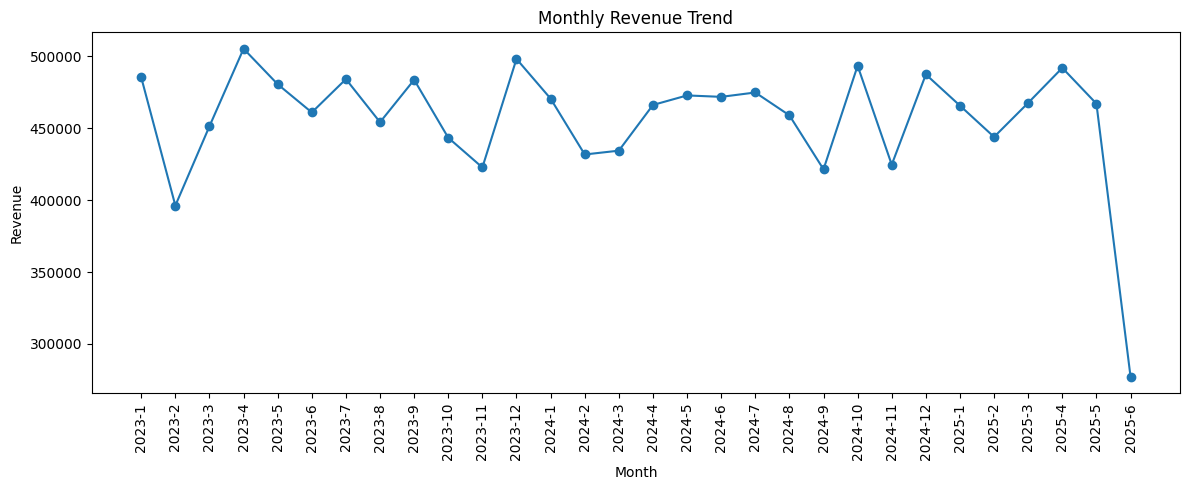

In [88]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["purchase_year"].astype(str) + "-" +
    monthly_sales["purchase_month"].astype(str),
    monthly_sales["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

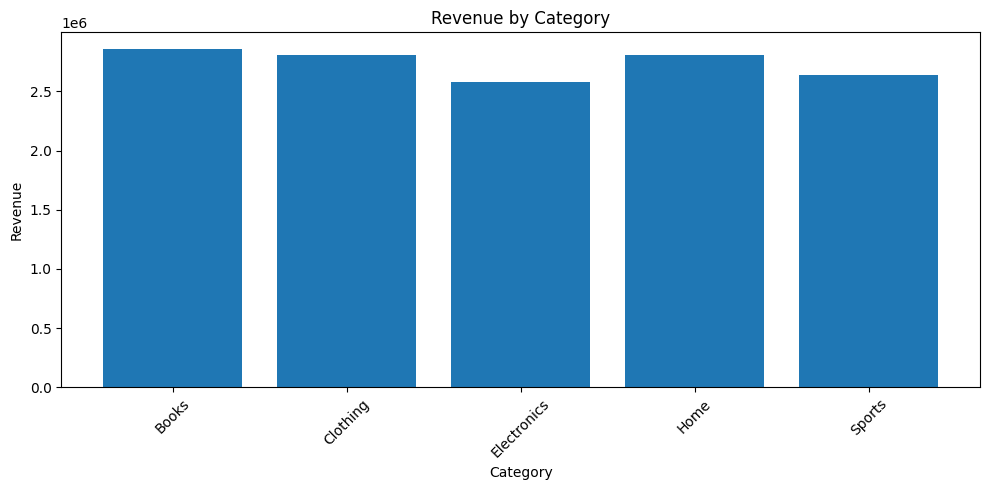

In [89]:
plt.figure(figsize=(10, 5))

plt.bar(
    category_sales["category"],
    category_sales["Revenue"]
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

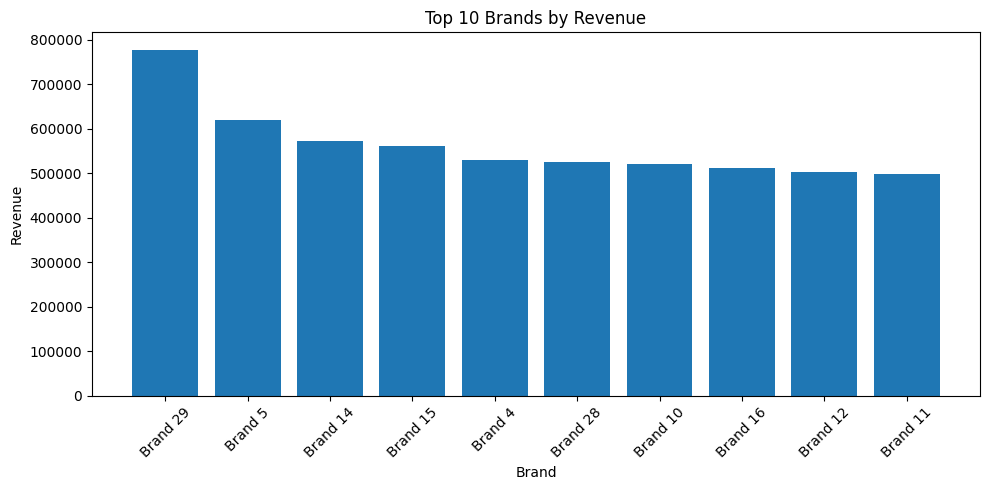

In [90]:
top_brands = brand_sales.sort_values(
    "Revenue", ascending=False
).head(10)

plt.figure(figsize=(10, 5))

plt.bar(
    top_brands["brand"],
    top_brands["Revenue"]
)

plt.title("Top 10 Brands by Revenue")
plt.xlabel("Brand")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

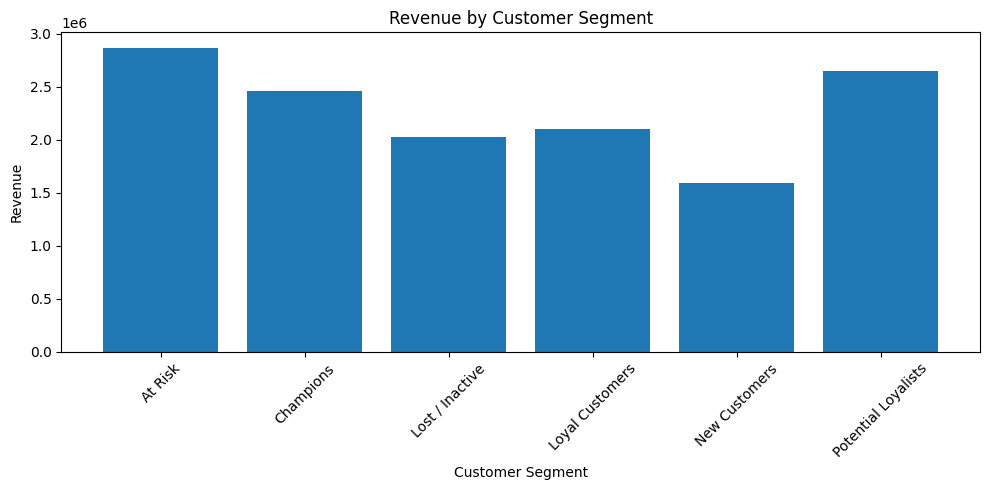

In [91]:
plt.figure(figsize=(10, 5))

plt.bar(
    segment_summary["Customer_Segment"],
    segment_summary["Total_Revenue"]
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

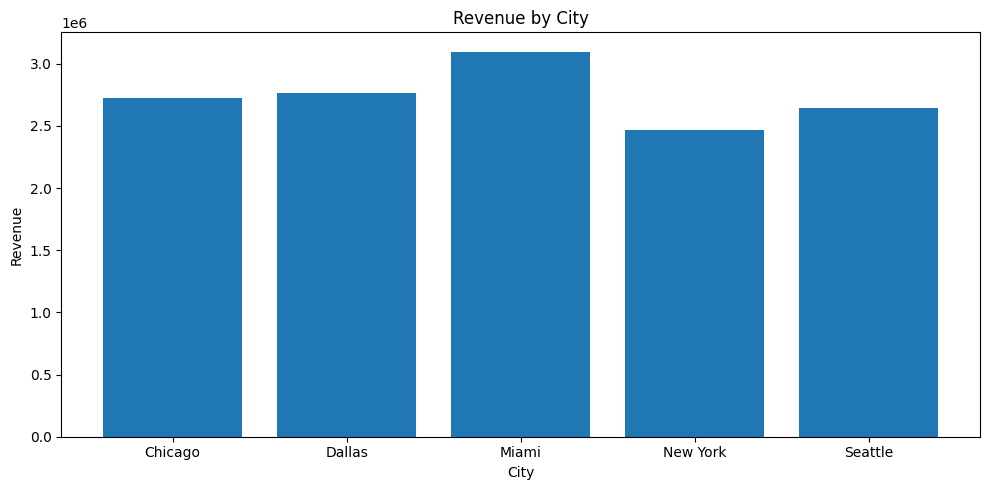

In [92]:
plt.figure(figsize=(10, 5))

plt.bar(
    city_sales["city"],
    city_sales["Revenue"]
)

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

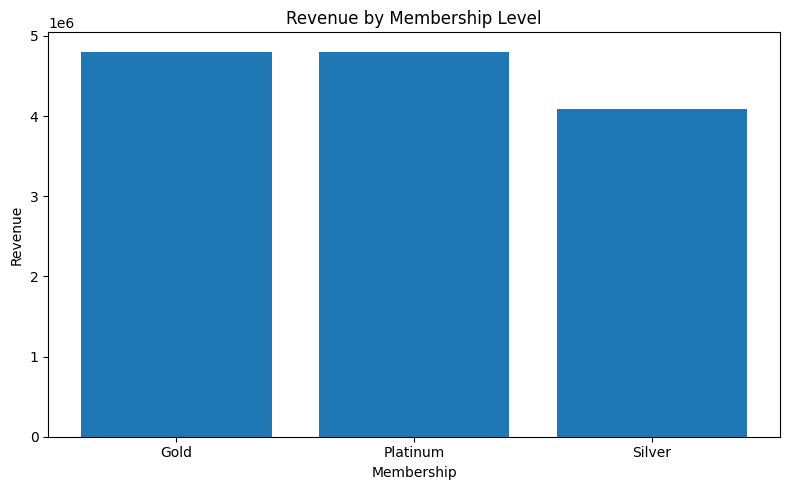

In [93]:
plt.figure(figsize=(8, 5))

plt.bar(
    membership_sales["membership"],
    membership_sales["Revenue"]
)

plt.title("Revenue by Membership Level")
plt.xlabel("Membership")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

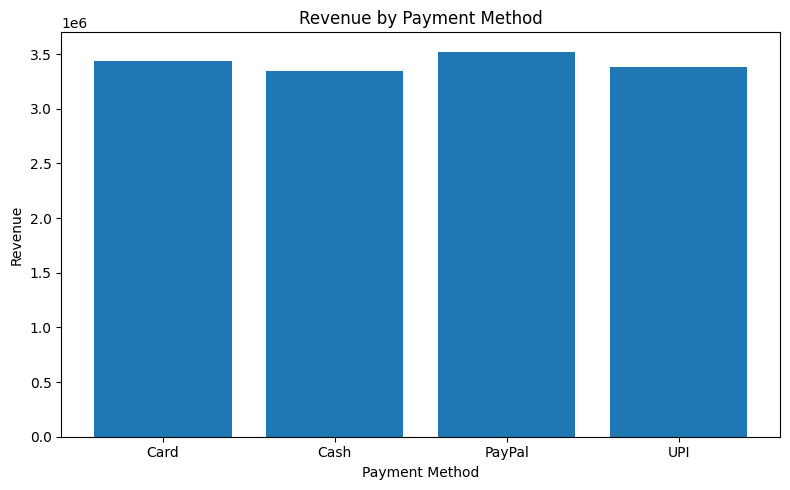

In [94]:
plt.figure(figsize=(8, 5))

plt.bar(
    payment_sales["payment_method"],
    payment_sales["Revenue"]
)

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

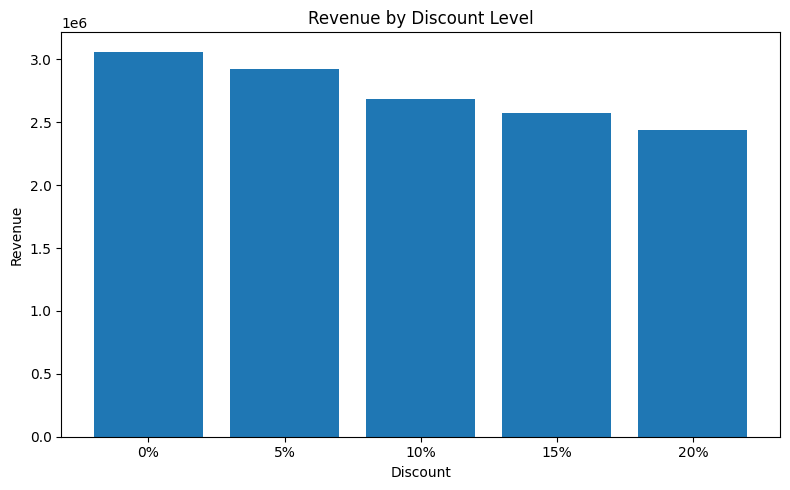

In [95]:
plt.figure(figsize=(8, 5))

plt.bar(
    discount_sales["discount"].astype(str) + "%",
    discount_sales["Revenue"]
)

plt.title("Revenue by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

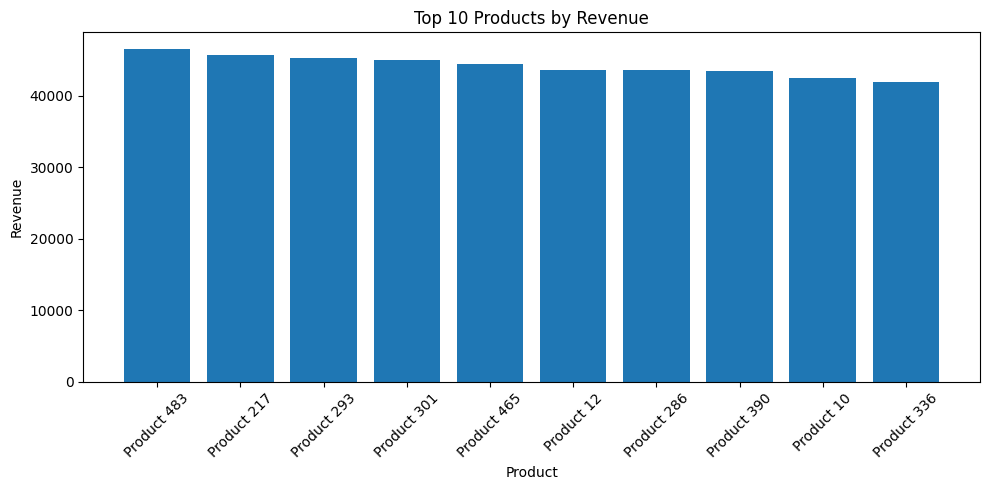

In [96]:
top_products = product_sales.sort_values(
    "Revenue", ascending=False
).head(10)

plt.figure(figsize=(10, 5))

plt.bar(
    top_products["product_name"],
    top_products["Revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()